In [8]:
import numpy as np
import h5py
import torch
from score_models import NCSNpp, ScoreModel
import torch.nn.functional as F
import os, re, json
from astropy.visualization import ImageNormalize, LogStretch, SqrtStretch
from glob import glob
from astropy.io import fits
from astropy import units as u
from astropy import units
from functorch import vjp, vmap, grad
from astropy.wcs import WCS
from tqdm import tqdm
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord


DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
def interpolate(image, coordinates):
    """
    Interpolation function, without a batch size. To make it batched, used vmap from functorch.
    """
    C, H, W = image.shape
    x, y = torch.tensor_split(coordinates, 2, dim=0)
    x = x.view(-1)
    y = y.view(-1)
    x0 = torch.floor(x).long()
    x1 = x0 + 1
    y0 = torch.floor(y).long()
    y1 = y0 + 1

    x0 = torch.clip(x0, 0, W - 1)
    x1 = torch.clip(x1, 0, W - 1)
    y0 = torch.clip(y0, 0, H - 1)
    y1 = torch.clip(y1, 0, H - 1)
    x = torch.clip(x, 0, W - 1)
    y = torch.clip(y, 0, H - 1)

    Ia = image[..., x0, y0]
    Ib = image[..., x0, y1]
    Ic = image[..., x1, y0]
    Id = image[..., x1, y1]

    wa = (x1 - x) * (y1 - y)
    wb = (x1 - x) * (y - y0)
    wc = (x - x0) * (y1 - y)
    wd = (x - x0) * (y - y0)

    _, new_H, new_W = coordinates.shape
    return (wa * Ia + wb * Ib + wc * Ic + wd * Id).view(C, new_H, new_W)

In [3]:
def make_wcs(skycoord, orientation, pixels, pixel_size):
    """
    Create a World Coordinate System (WCS) object based on the given parameters.

    Parameters:
    skycoord (SkyCoord): The sky coordinates of the center of the image.
    orientation (float): The orientation of the image, defined as East of North in world coordinates.
    pixels (int): The number of pixels in each dimension of the image.
    pixel_size (Quantity): The size of each pixel in angular units.

    Returns:
    WCS: The World Coordinate System object.

    Raises:
    None.

    This function creates a FITS header and populates it with the necessary keywords to define a WCS.
    The FITS header is then used to create a WCS object, which can be used to convert between pixel coordinates and sky coordinates.

    The FITS header is populated with the following keywords:
    - NAXIS1: The number of pixels in the x-axis of the image.
    - NAXIS2: The number of pixels in the y-axis of the image.
    - CRVAL1: The right ascension of the center of the image in degrees.
    - CRVAL2: The declination of the center of the image in degrees.
    - CUNIT1: The units of the x-axis coordinates (degrees).
    - CUNIT2: The units of the y-axis coordinates (degrees).
    - CTYPE1: The coordinate type of the x-axis (RA---TAN).
    - CTYPE2: The coordinate type of the y-axis (DEC--TAN).
    - PCi_j: Elements of the pixel scale matrix for converting from pixel coordinates to sky coordinates.

    The orientation of the image is defined as East of North in world coordinates.
    To convert the orientation to pixel coordinate rotation, a 90 degree rotation is added.
    The rotation matrix is then calculated using the pixel size and the rotated orientation.
    The rotation matrix accounts for the mirror flip of the y-axis pixel coordinate (East<-West).

    The WCS object is created using the FITS header and returned.
    """
    hdr = fits.Header()
    hdr["NAXIS1"] = pixels
    hdr["NAXIS2"] = pixels
    hdr["CRVAL1"] = skycoord.ra.to(units.deg).value
    hdr["CRVAL2"] = skycoord.dec.to(units.deg).value
    hdr["CRPIX1"] = pixels/2 - 0.5 # Same convention as Cutout2D
    hdr["CRPIX2"] = pixels/2 - 0.5
    hdr["CUNIT1"] = 'deg'
    hdr["CUNIT2"] = 'deg'
    hdr["CTYPE1"] = "RA---TAN"
    hdr["CTYPE2"] = "DEC--TAN"
    hdr["CDELT1"] = pixel_size.to(units.deg).value
    hdr["CDELT2"] = pixel_size.to(units.deg).value
    theta = orientation * np.pi / 180
    rotation = np.array([[np.cos(theta), -np.sin(theta)], 
                         [np.sin(theta), np.cos(theta)]])
    mirror_j = np.array([[1, 0], [0, -1]])
    pc = rotation @ mirror_j
    hdr["PC1_1"] = pc[0, 0]
    hdr["PC1_2"] = pc[0, 1]
    hdr["PC2_1"] = pc[1, 0]
    hdr["PC2_2"] = pc[1, 1]
    return WCS(hdr)
    
def make_forward_model(
        psf:np.ndarray, 
        wcs_list:list[WCS, ...], 
        super_sampling_factor:int,
        model_pixels:int,
        model_pixel_size:units.Quantity,
        zero_padding:int=0,
        fiducial_center:SkyCoord=None,
        fiducial_orientation:float=None, # Pick the orientation of the first WCS, angle East of North
        **kwargs
        ):
    """
    Create a forward model for a given point spread function (PSF) and a list of world coordinate systems (WCS).

    Parameters:
    -----------
    psf : np.ndarray
        The point spread function (PSF) to be used for the forward model. It should be a 2D or 3D array (multi channel fit).

    wcs_list : list[WCS, ...]
        A list of world coordinate systems (astropy WCS) to be used for the forward model. 

    super_sampling_factor : int
        The super sampling factor to be used for the forward model. It determines the level of detail in the model.

    model_pixels : int
        The number of pixels to be used for the model pixel grid.

    model_pixel_size : units.Quantity
        The size of each pixel in the model pixel grid. It should be an instance of the units.Quantity class.

    zero_padding : int, optional
        The number of zero padding pixels to be added to the model pixel grid on each side. Default is 0.

    fiducial_center : SkyCoord, optional
        The fiducial center to be used for the model reference pixel. It should be an instance of the SkyCoord class. 
        Default (None) is to use first WCS center pixel world coordinate.
        
    fiducial_orientation : float, optional
        The fiducial orientation to be used for model pixel grid. The angle is defined East of North. 
        Default (None) is to use first WCS pixel scale matrix orientation.

    Returns:
    --------
    forward_model : np.ndarray
        The created forward model as a 2D array.

    Examples:
    ---------
    >>> psf = np.ones((5, 5))
    >>> wcs_list = [WCS(), WCS()]
    >>> super_sampling_factor = 2
    >>> model_pixels = 10
    >>> model_pixel_size = units.Quantity(0.1, 'arcsec')
    >>> forward_model = make_forward_model(psf, wcs_list, super_sampling_factor, model_pixels, model_pixel_size)
    """
    if psf.ndim == 2:
        C = 1
        H, W = psf.shape
    elif psf.ndim == 3:
        C, H, W = psf.shape
    psf = torch.tensor(psf).float().to(DEVICE).view(C, 1, H, W) # reshape to a convolution kernel [channel_out, channels_in/groups, H, W]
    batched_interpolation = vmap(interpolate, in_dims=(0, None))  # only batch over the images (first argument of interpolate)
    
    if fiducial_center is None:
        # Use same convention as Cutout2D for reference pixel
        center = [dim / 2 - 0.5 for dim in wcs_list[0].pixel_shape]
        fiducial_center = wcs_list[0].pixel_to_world(*center)
    if fiducial_orientation is None:
        pc = wcs_list[0].pixel_scale_matrix
        fiducial_orientation = np.arctan2(pc[1, 0], pc[0, 0]) * 180 / np.pi
    fiducial_wcs = make_wcs(fiducial_center, fiducial_orientation, model_pixels, model_pixel_size)

    # Prepare coordinate systems
    model_coordinates_list = []
    for wcs in wcs_list:
        # Observation pixel coordinates super sampled
        u = (np.arange(super_sampling_factor * wcs.pixel_shape[0]) + 0.5) / super_sampling_factor 
        v = (np.arange(super_sampling_factor * wcs.pixel_shape[1]) + 0.5) / super_sampling_factor 
        # v = np.flip(v) # Remember matrix convention for pixel indexing
        u, v = np.meshgrid(u, v, indexing="ij")
        world = wcs.pixel_to_world(u, v)
        model_coordinates = np.stack(fiducial_wcs.world_to_pixel(world), axis=0)
        model_coordinates_list.append(torch.tensor(model_coordinates).float().to(DEVICE))
    
    def A(x):
        x = F.pad(x, pad=[zero_padding]*4, mode="constant", value=0.)
        ys = []
        for i in range(len(wcs_list)):
            y = batched_interpolation(x, model_coordinates_list[i])
            y = F.conv2d(y, psf, groups=C, padding="same")
            y = F.avg_pool2d(y, kernel_size=super_sampling_factor, stride=super_sampling_factor)
            ys.append(y)
        return torch.concat(ys, dim=1)
    return A

In [4]:
# slic_path = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpp_hst_noise_psf_f814w_wfc3uv_230603210517"
# slic_path = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpp_hst_noise_flat_field_psf_f814w_wfc3uv_ssf4_flux_lt_0.013_230718172645"
# prior_path = "/home/aadam/projects/rrg-lplevass/data/score_models/ncsnpp_ct_g_220912024942"

slic_model = ScoreModel(checkpoints_directory=slic_path)
prior_model = ScoreModel(checkpoints_directory=prior_path)

In [14]:
i = 0
coord0 = SkyCoord("7:23:24.5462", "-73:27:20.172", unit=(u.hourangle, u.deg))
coord1 = SkyCoord("7:23:22.0805", "-73:27:24.575", unit=(u.hourangle, u.deg))
coord2 = SkyCoord("7:23:20.7483", "-73:26:07.203", unit=(u.hourangle, u.deg))
coord3 = SkyCoord("7:23:01.6118", "-73:26:45.888", unit=(u.hourangle, u.deg))

FILTER = "F105W" # "F125W", "F160W
paths = glob(f"../data/smacs*target{i}*{FILTER}*.fits")
data = []
for p in paths:
    data.append(fits.open(p))

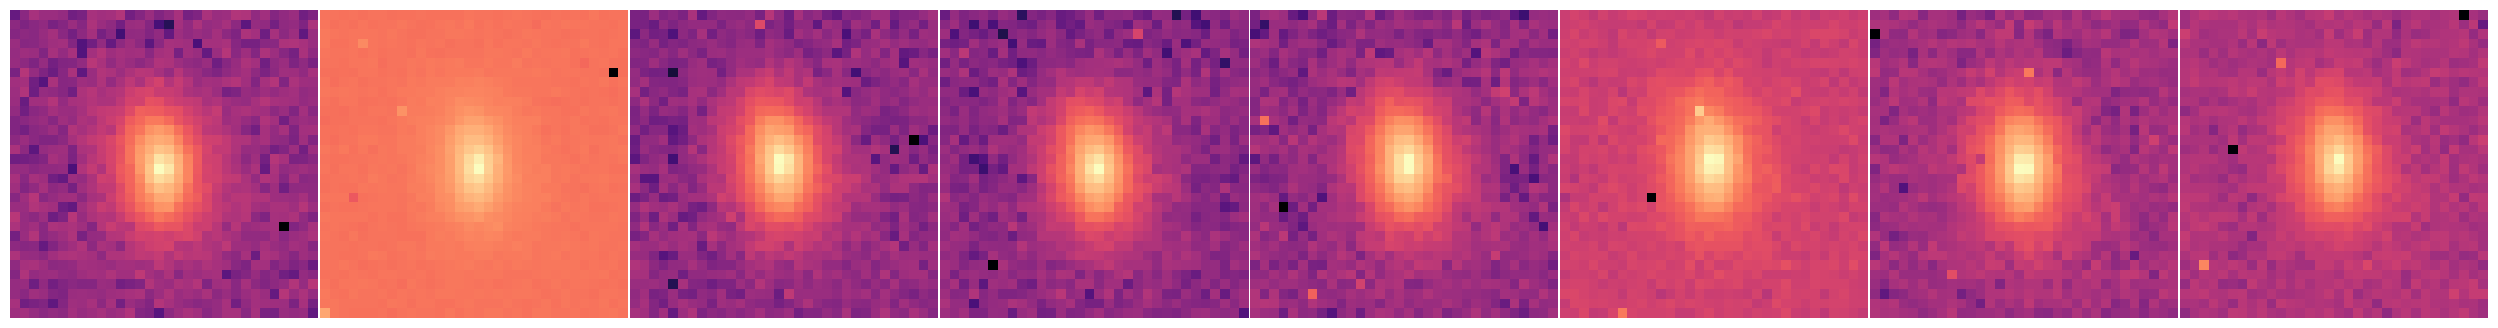

In [22]:
fig, axs = plt.subplots(1, len(data), figsize=(4*len(data), 4))

vmin = 1e-3
for i in range(len(data)):
    axs[i].imshow(data[i]["SCI"].data, cmap="magma", norm=ImageNormalize(stretch=LogStretch()))
    axs[i].axis("off")
plt.subplots_adjust(wspace=0, hspace=0)